In [2]:
REPO_ROOT = "../"

%matplotlib inline
import os
os.chdir(os.path.dirname(REPO_ROOT))
%load_ext autoreload
from argparse import Namespace
import segmentation.utils as utils
from pretrain.mae.lit_mae import LitMAE
import torch
from retrieval.knn_seg_hbird import KNNHummingBirdSegmentation
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from data.semantic_module import SemanticDataModule
from data.retrieval_module import RetrievalDataModule
import albumentations as A
import cv2

# Set random seeds
seed = 42
pl.seed_everything(seed, workers=True)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# Enhanced thesis-ready configuration
plt.rcParams['font.size'] = 14          # Slightly larger base font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 18     # More prominent titles
plt.rcParams['axes.labelsize'] = 14     # Clearer axis labels
plt.rcParams['xtick.labelsize'] = 12    # Readable tick labels
plt.rcParams['ytick.labelsize'] = 12    # Readable tick labels
plt.rcParams['legend.fontsize'] = 12    # Add legend font size
plt.rcParams['figure.titlesize'] = 20   # Overall figure title
plt.rcParams['lines.linewidth'] = 2     # Thicker lines for clarity
plt.rcParams['axes.linewidth'] = 1.2    # Thicker axes
plt.rcParams['grid.alpha'] = 0.3        # Subtle grid if used
plt.rcParams['savefig.dpi'] = 300       # High resolution for print
plt.rcParams['savefig.bbox'] = 'tight'  # Remove extra whitespace
plt.rcParams['figure.figsize'] = (8, 6) # Good default size

/home/joaquin/phd/projects/aoi-ssl/segmentation/models/vit/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/joaquin/phd/projects/aoi-ssl/segmentation/models/vit/layers/attention.py:23: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/joaquin/miniforge3/envs/aoi-ssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/joaquin/miniforge3/envs/aoi-ssl/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/joaquin/phd/projects/aoi-ssl/segmentation/models/vit/layers

# MAE Results

### Initialization

In [ ]:
os.sync()
with open(f"{REPO_ROOT}/retrieval/knn_seg_hbird.py", "r") as f:
    t = f.read()
    print(t)

with open(f"{REPO_ROOT}/data/retrieval_dataset.py", "r") as f:
    t = f.read()
    print(t)


%autoreload 2
config_path = "./configs/finetune/finetune_main.yml"
model_config_path = "./configs/finetune/finetune_knn_test.yml"

args = Namespace()

config = utils.merge_config(config_path, args, model_config_path)

config.model_params = utils.merge_model_params_segementation_encoder(
    config, config.encoder_ckpt_model_params)

#config.data_path = "./datasets/finetune/epoxy/0.6.57/"
config.data_path = "./datasets/pretrain_split/"

config.encoder_ckpt_path = f"{REPO_ROOT}/scripts/logs/31108_good_epoch=6158-val_loss=0.003.ckpt"
#config.ckpt_path = f"{REPO_ROOT}/checkpoints/pretrain-vit-dino-more-augmentations/aoi-pretrain-dino_40012/epoch=239-val_knn_mean_iou=0.506.ckpt"

config.input_resolution = [512, 512]

print("Configuration after merge: ", config)

mae = LitMAE.load_from_checkpoint(
    config.encoder_ckpt_path, parameters=config.model_params,
    strict=False
)

config.normalize = False

encoder = mae.get_encoder()
torch.cuda.memory_allocated() / (1024**2)

# Adapted from: https://github.com/vpariza/open-hummingbird-eval/blob/main/hbird/hbird_eval.py

# should use precomputed representations of training data
# let's first try to see if data fits in memory 


import torch
from segmentation.data.semantic_dataset import SemanticDataset
from segmentation.data.retrieval_dataset import RetrievalDataset
import os
import numpy as np
import h5py
from torch.utils.data import DataLoader
import torch.nn.functional as F
from pathlib import Path
from torchmetrics import JaccardIndex
from torchmetrics.wrappers import ClasswiseWrapper
from segmentation.models.mae.lit_mae_dino import LitMAE
from tools.hbird_eval_metrics import PredsmIoU
from argparse import ArgumentParser
from argparse import Namespace
import segmentation.utils as utils
import albumentations as A
import cv2
import psutil
import time
import psutil
import random
import faiss
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple, Dict
from collections import defaultdict
fro

<HOME>/miniconda3/envs/thesis/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['model.decoder.mask_token', 'model.decoder.pos_embed', 'model.decoder.decoder_embed.weight', 'model.decoder.decoder_embed.bias', 'model.decoder.blocks.0.norm1.weight', 'model.decoder.blocks.0.norm1.bias', 'model.decoder.blocks.0.attn.qkv.weight', 'model.decoder.blocks.0.attn.qkv.bias', 'model.decoder.blocks.0.attn.proj.weight', 'model.decoder.blocks.0.attn.proj.bias', 'model.decoder.blocks.0.norm2.weight', 'model.decoder.blocks.0.norm2.bias', 'model.decoder.blocks.0.mlp.fc1.weight', 'model.decoder.blocks.0.mlp.fc1.bias', 'model.decoder.blocks.0.mlp.fc2.weight', 'model.decoder.blocks.0.mlp.fc2.bias', 'model.decoder.blocks.1.norm1.weight', 'model.decoder.blocks.1.norm1.bias', 'model.decoder.blocks.1.attn.qkv.weight', 'model.decoder.blocks.1.attn.qkv.bias', 'model.decoder.blocks.1.attn.proj.weight', 'model.decoder.blocks.1

218.9453125

## Average

In [3]:
retrieval_module = RetrievalDataModule(
    data_path="./datasets/pretrain_split/",
    batch_size=32,
    classes=config.classes,
    num_workers=4,
    input_resolution=config.input_resolution,
    train_size=0.8,
)

retrieval_module.setup("train")

train_loader = retrieval_module.train_dataloader()
val_loader = retrieval_module.val_dataloader()

0.8
500


In [4]:
knn_evaluator = KNNHummingBirdSegmentation(
    encoder=encoder,
    normalize=config.normalize,
    train_loader=train_loader,
    val_loader=val_loader,
    classes=config.classes,
)

Dataset size: 400
Finished creating memory with 409600 features and 409600 labels.
Using Replicated index


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from pathlib import Path

class_map ={
    0: "wire",
    1: "ball",
    2: "wedge",
    3: "epoxy"
}

def evaluate_with_kfold(encoder, config, k_folds=5, random_state=42, 
                        num_classes=4):
    """
    Use K-fold cross validation for each hyperparameter combination
    """
    from sklearn.model_selection import KFold
    
    # Get all images
    data_path = Path(config.data_path)
    im_list = [data_path / "train" / img_file for img_file in os.listdir(data_path / "train")]
    
    # Create K-fold splits
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    
    # Hyperparameter grid
    thresholds = [0.5, 0.2, 0.1, 0.05, 0.01]
    betas = [0.3, 0.15, 0.1, 0.02, 0.002]
    ks = [2, 10, 20, 30, 50]
    
    all_results = []
    
    for k in ks:
        for threshold in thresholds:
            for beta in betas:
                print(f"\n=== Testing k={k}, threshold={threshold}, beta={beta} ===")
                
                fold_results = {cls: [] for cls in config.classes}
                
                # K-fold evaluation
                for fold, (train_indices, val_indices) in enumerate(kf.split(im_list)):
                    print(f"  Fold {fold + 1}/{k_folds}")
                    
                    # Create fold-specific image lists
                    train_im_list = [im_list[i] for i in train_indices]
                    val_im_list = [im_list[i] for i in val_indices]
                    
                    # Create evaluator for this fold
                    fold_evaluator = KNNHummingBirdSegmentation(
                        encoder=encoder,
                        train_im_list=train_im_list,
                        val_im_list=val_im_list,
                        num_batches=-1,
                        profile_time=True,
                        normalize=False
                    )
                    
                    # Evaluate
                    m_ious = fold_evaluator.evaluate(
                        thresholds=[threshold]*num_classes,
                        betas=[beta]*num_classes,
                        k=k,
                        patch_mechanism="average",
                    )
                    
                    
                    # Store results
                    for cls in class_map.values():
                        if m_ious[cls] is not None:
                            fold_results[cls].append(m_ious[cls])
                    
                    del fold_evaluator
                    torch.cuda.empty_cache()
                
                # Calculate statistics
                for cls in class_map.values():
                    class_scores = fold_results[cls]
                    all_results.append({
                        'class': cls,
                        'threshold': threshold,
                        'beta': beta,
                        'fold_scores': class_scores,
                        'mean_miou': np.mean(class_scores) if class_scores else None,
                        'std_miou': np.std(class_scores) if class_scores else None,
                        'cv_score': np.mean(class_scores) - np.std(class_scores) if class_scores else None  # Conservative estimate
                    })
        
        return pd.DataFrame(all_results)

# Run K-fold evaluation
results_df = evaluate_with_kfold(encoder, config, k_folds=5, random_state=42)


=== Testing k=2, threshold=0.5, beta=0.3 ===
  Fold 1/5
Dataset size: 400
Time taken to access data: 3.38 seconds
Time taken to access data: 2.38 seconds
Time taken to access data: 0.08 seconds
Time taken to access data: 0.11 seconds
Time taken to access data: 1.09 seconds
Time taken to access data: 3.79 seconds
Time taken to access data: 0.08 seconds
Time taken to access data: 0.92 seconds
Time taken to access data: 0.08 seconds
Time taken to access data: 1.61 seconds
Time taken to access data: 0.04 seconds
Time taken to access data: 1.46 seconds
Time taken to access data: 0.04 seconds
Finished creating memory with 409600 features and 409600 labels.
Using Replicated index
Cross-attention with beta: [0.3, 0.3, 0.3, 0.3], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 2, 384]), v shape: torch.Size([32, 1024, 2, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
True Positives: [0, 0, 0, 0], False Positives: [0, 0, 0, 0], False Negatives: [184443, 53704, 9652, 1

In [12]:
results_df.to_csv("mae_hbird_kfold_evaluation_results.csv", index=False)

In [14]:
results_df = pd.read_csv("mae_hbird_kfold_evaluation_results.csv")

results_df.groupby('class').max('mean_miou').sort_values(by="mean_miou", ascending=False)

,threshold,beta,mean_miou,std_miou,cv_score
class,,,,,
epoxy,0.5,0.3,0.086434,0.014346,0.072161
wire,0.5,0.3,0.063147,0.008882,0.054672
ball,0.5,0.3,0.025783,0.006824,0.020620
wedge,0.5,0.3,0.004500,0.003919,0.000891


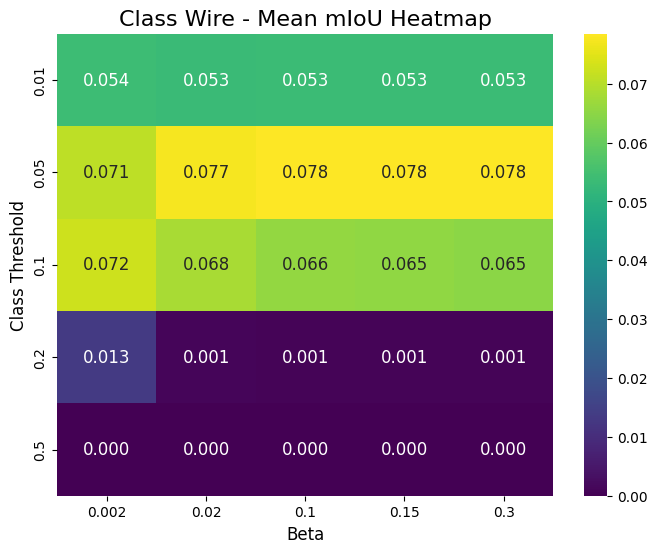

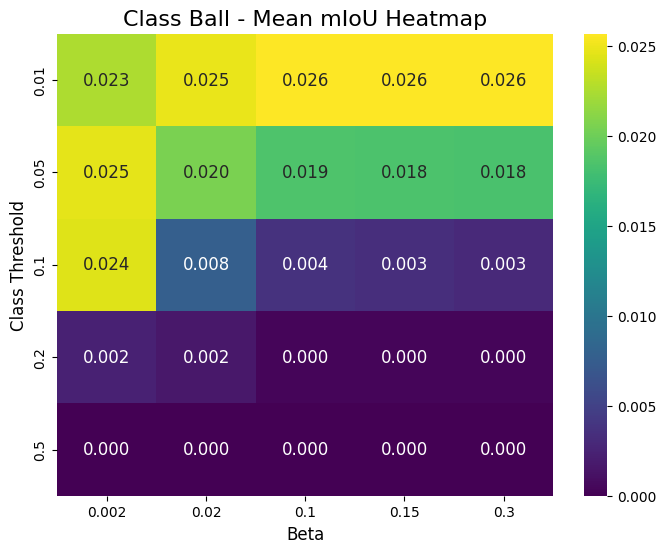

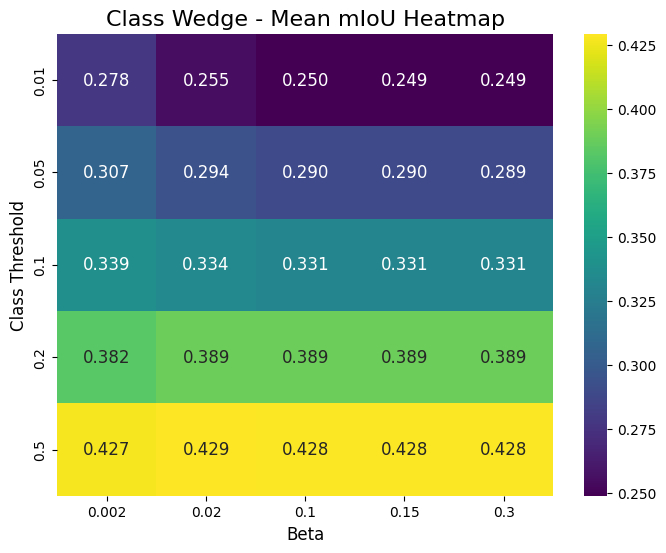

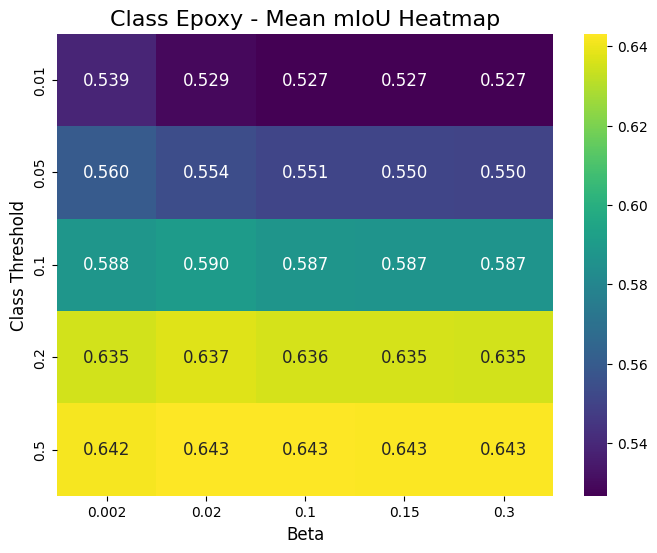

In [45]:
import seaborn as sns

grouped_results =  results_df.groupby(['class', 'threshold', 'beta']).\
    max('mean_miou')["mean_miou"].\
    reset_index()

import matplotlib.pyplot as plt

class_map ={
    0: "Wire",
    1: "Ball",
    2: "Wedge",
    3: "Epoxy"
}

for cls, name in [(c, class_map[c]) for c in grouped_results['class'].unique()]:
    data = grouped_results[grouped_results['class'] == cls]
    heatmap_data = data.pivot(index='threshold', columns='beta', values='mean_miou')
    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis")
    plt.title(f"Class {name} - Mean mIoU Heatmap")
    plt.xlabel("Beta")
    plt.ylabel("Class Threshold")
    plt.savefig(f"visualizations/hbird_hyper_heatmap_class_{cls}.pdf", bbox_inches='tight')
    plt.show()

## Complete

In [ ]:
os.sync()
with open(f"{REPO_ROOT}/retrieval/knn_seg_hbird.py", "r") as f:
    t = f.read()
    print(t)

with open(f"{REPO_ROOT}/data/retrieval_dataset.py", "r") as f:
    t = f.read()
    print(t)


%autoreload 2
config_path = "./configs/finetune/finetune_main.yml"
model_config_path = "./configs/finetune/finetune_knn_test.yml"

args = Namespace()

config = utils.merge_config(config_path, args, model_config_path)

config.model_params = utils.merge_model_params_segementation_encoder(
    config, config.encoder_ckpt_model_params)

#config.data_path = "./datasets/finetune/epoxy/0.6.57/"
config.data_path = "./datasets/pretrain_split/"

config.encoder_ckpt_path = f"{REPO_ROOT}/scripts/logs/31108_good_epoch=6158-val_loss=0.003.ckpt"
#config.ckpt_path = f"{REPO_ROOT}/checkpoints/pretrain-vit-dino-more-augmentations/aoi-pretrain-dino_40012/epoch=239-val_knn_mean_iou=0.506.ckpt"

print("Configuration after merge: ", config)

mae = LitMAE.load_from_checkpoint(
    config.encoder_ckpt_path, parameters=config.model_params,
    strict=False
)

config.normalize = False

encoder = mae.get_encoder()
torch.cuda.memory_allocated() / (1024**2)

# Adapted from: https://github.com/vpariza/open-hummingbird-eval/blob/main/hbird/hbird_eval.py

# should use precomputed representations of training data
# let's first try to see if data fits in memory 


import torch
from segmentation.data.semantic_dataset import SemanticDataset
from segmentation.data.retrieval_dataset import RetrievalDataset
import os
import numpy as np
import h5py
from torch.utils.data import DataLoader
import torch.nn.functional as F
from pathlib import Path
from torchmetrics import JaccardIndex
from torchmetrics.wrappers import ClasswiseWrapper
from segmentation.models.mae.lit_mae_dino import LitMAE
from tools.hbird_eval_metrics import PredsmIoU
from argparse import ArgumentParser
from argparse import Namespace
import segmentation.utils as utils
import albumentations as A
import cv2
import psutil
import time
import psutil
import random
import faiss
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple, Dict
from collections import defaultdict
fro

<HOME>/miniconda3/envs/thesis/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['model.decoder.mask_token', 'model.decoder.pos_embed', 'model.decoder.decoder_embed.weight', 'model.decoder.decoder_embed.bias', 'model.decoder.blocks.0.norm1.weight', 'model.decoder.blocks.0.norm1.bias', 'model.decoder.blocks.0.attn.qkv.weight', 'model.decoder.blocks.0.attn.qkv.bias', 'model.decoder.blocks.0.attn.proj.weight', 'model.decoder.blocks.0.attn.proj.bias', 'model.decoder.blocks.0.norm2.weight', 'model.decoder.blocks.0.norm2.bias', 'model.decoder.blocks.0.mlp.fc1.weight', 'model.decoder.blocks.0.mlp.fc1.bias', 'model.decoder.blocks.0.mlp.fc2.weight', 'model.decoder.blocks.0.mlp.fc2.bias', 'model.decoder.blocks.1.norm1.weight', 'model.decoder.blocks.1.norm1.bias', 'model.decoder.blocks.1.attn.qkv.weight', 'model.decoder.blocks.1.attn.qkv.bias', 'model.decoder.blocks.1.attn.proj.weight', 'model.decoder.blocks.1

218.9453125

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from pathlib import Path

class_map ={
    0: "wire",
    1: "ball",
    2: "wedge",
    3: "epoxy"
}

def evaluate_with_kfold(encoder, config, k_folds=5, random_state=42, 
                        num_classes=4):
    """
    Use K-fold cross validation for each hyperparameter combination
    """
    from sklearn.model_selection import KFold
    
    # Get all images
    data_path = Path(config.data_path)
    im_list = [data_path / "train" / img_file for img_file in os.listdir(data_path / "train")]
    
    # Create K-fold splits
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    
    # Hyperparameter grid
    thresholds = [0.5, 0.2, 0.1, 0.05, 0.01]
    betas = [0.3, 0.15, 0.1, 0.02, 0.002]
    ks = [2, 10, 20, 30, 50]
    
    all_results = []
    
    for k in ks:
        for threshold in thresholds:
            for beta in betas:
                print(f"\n=== Testing k={k}, threshold={threshold}, beta={beta} ===")
                
                fold_results = {cls: [] for cls in config.classes}
                
                # K-fold evaluation
                for fold, (train_indices, val_indices) in enumerate(kf.split(im_list)):
                    print(f"  Fold {fold + 1}/{k_folds}")
                    
                    # Create fold-specific image lists
                    train_im_list = [im_list[i] for i in train_indices]
                    val_im_list = [im_list[i] for i in val_indices]
                    
                    # Create evaluator for this fold
                    fold_evaluator = KNNHummingBirdSegmentation(
                        encoder=encoder,
                        train_im_list=train_im_list,
                        val_im_list=val_im_list,
                        num_batches=-1,
                        profile_time=True,
                        normalize=False,
                        average_patches=False
                    )
                    
                    # Evaluate
                    m_ious = fold_evaluator.evaluate(
                        thresholds=[threshold]*num_classes,
                        betas=beta,
                        k=k,
                        patch_mechanism="complete",
                    )
                    
                    
                    # Store results
                    for cls in class_map.values():
                        if m_ious[cls] is not None:
                            fold_results[cls].append(m_ious[cls])
                    
                    del fold_evaluator
                    torch.cuda.empty_cache()
                
                # Calculate statistics
                for cls in class_map.values():
                    class_scores = fold_results[cls]
                    all_results.append({
                        'class': cls,
                        'threshold': threshold,
                        'beta': beta,
                        'fold_scores': class_scores,
                        'mean_miou': np.mean(class_scores) if class_scores else None,
                        'std_miou': np.std(class_scores) if class_scores else None,
                        'cv_score': np.mean(class_scores) - np.std(class_scores) if class_scores else None  # Conservative estimate
                    })
        
        return pd.DataFrame(all_results)

# Run K-fold evaluation
results_df = evaluate_with_kfold(encoder, config, k_folds=5, random_state=42)


=== Testing k=2, threshold=0.5, beta=0.3 ===
  Fold 1/5
Dataset size: 400
Time taken to access data: 109.76 seconds
Time taken to access data: 136.78 seconds
Time taken to access data: 0.09 seconds
Time taken to access data: 0.10 seconds
Time taken to access data: 41.34 seconds
Time taken to access data: 199.01 seconds
Time taken to access data: 0.09 seconds
Time taken to access data: 0.06 seconds
Time taken to access data: 0.23 seconds
Time taken to access data: 1.85 seconds
Time taken to access data: 0.05 seconds
Time taken to access data: 0.05 seconds
Time taken to access data: 0.05 seconds
Finished creating memory with 409600 features and 409600 labels.
Using Replicated index
patch_size: 16
input_resolution: (512, 512)
eval_spatial_resolution: 32
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
True Positives: [13714, 1661, 76, 13980], False Positives: [174810, 56417, 7813, 145760], False Negatives: [170729, 52043, 9576, 99122]
Mean IoUs:  [0.03817365477810902, 0.0150834082509239

In [5]:
results_df.to_csv("mae_hbird_complete_patches_kfold_evaluation_results.csv", index=False)

In [6]:
results_df = pd.read_csv("mae_hbird_complete_patches_kfold_evaluation_results.csv")

results_df.groupby('class').max('mean_miou').sort_values(by="mean_miou", ascending=False)

,threshold,beta,mean_miou,std_miou,cv_score
class,,,,,
epoxy,0.5,0.3,0.043723,0.005007,0.039031
wire,0.5,0.3,0.041614,0.003821,0.038083
ball,0.5,0.3,0.016142,0.002411,0.013781
wedge,0.5,0.3,0.002803,0.002367,0.000772


## Distance

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from pathlib import Path

class_map ={
    0: "iou_wire",
    1: "iou_ball",
    2: "iou_wedge",
    3: "iou_epoxy"
}

def evaluate_with_kfold(encoder, config, k_folds=5, random_state=42, 
                        num_classes=4):
    """
    Use K-fold cross validation for each hyperparameter combination
    """
    from sklearn.model_selection import KFold
    
    # Get all images
    data_path = Path(config.data_path)
    im_list = [data_path / "train" / img_file for img_file in os.listdir(data_path / "train")]
    
    # Create K-fold splits
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)
    
    # Hyperparameter grid
    thresholds = [0.5, 0.2, 0.1, 0.05, 0.01]
    betas = [0.3, 0.15, 0.1, 0.02, 0.002]
    ks = [2, 4, 6, 10, 20, 30]
    
    all_results = []
    
    for k in ks:
        for threshold in thresholds:
                print(f"\n=== Testing k={k}, threshold={threshold} ===")
                
                fold_results = {f"iou_{cls}": [] for cls in config.classes}
                
                # K-fold evaluation
                for fold, (train_indices, val_indices) in enumerate(kf.split(im_list)):
                    print(f"  Fold {fold + 1}/{k_folds}")
                    
                    # Create fold-specific image lists
                    train_im_list = [im_list[i] for i in train_indices]
                    val_im_list = [im_list[i] for i in val_indices]
                    
                    # Create evaluator for this fold
                    fold_evaluator = KNNHummingBirdSegmentation(
                        encoder=encoder,
                        train_im_list=train_im_list,
                        val_im_list=val_im_list,
                        num_batches=-1,
                        profile_time=True,
                        normalize=False
                    )
                    
                    # Evaluate
                    m_ious = fold_evaluator.evaluate_distance(
                        threshold=threshold,
                        k=k,
                    )
                    
                    print(m_ious)
                    print(class_map.values())
                    # Store results
                    for cls in class_map.values():
                        if m_ious[cls] is not None:
                            fold_results[cls].append(m_ious[cls])
                    
                    del fold_evaluator
                    torch.cuda.empty_cache()
                
                # Calculate statistics
                for cls in class_map.values():
                    class_scores = fold_results[cls]
                    all_results.append({
                        'class': cls,
                        'k': k,
                        'threshold': threshold,
                        'fold_scores': class_scores,
                        'mean_miou': np.mean(class_scores) if class_scores else None,
                        'std_miou': np.std(class_scores) if class_scores else None,
                        'cv_score': np.mean(class_scores) - np.std(class_scores) if class_scores else None  # Conservative estimate
                    })
        
        return pd.DataFrame(all_results)

# Run K-fold evaluation
results_df = evaluate_with_kfold(encoder, config, k_folds=5, random_state=42)


=== Testing k=2, threshold=0.5 ===
  Fold 1/5
Dataset size: 400
Time taken to access data: 5.83 seconds
Time taken to access data: 0.08 seconds
Time taken to access data: 1.19 seconds
Time taken to access data: 0.08 seconds
Time taken to access data: 4.16 seconds
Time taken to access data: 0.07 seconds
Time taken to access data: 0.07 seconds
Time taken to access data: 0.09 seconds
Time taken to access data: 3.70 seconds
Time taken to access data: 0.04 seconds
Time taken to access data: 0.04 seconds
Time taken to access data: 0.04 seconds
Time taken to access data: 1.07 seconds
Finished creating memory with 409600 features and 409600 labels.
Using Replicated index
Class mask shape: torch.Size([32, 4, 512, 512])
Key features shape: torch.Size([32, 1024, 2, 384]), Key labels shape: torch.Size([32, 1024, 2, 4]), Distances shape: torch.Size([32, 1024, 2])
Combined labels shape after thresholding: torch.Size([32, 4, 512, 512])
Classwise IoUs: {'iou_wire': tensor(0.), 'iou_ball': tensor(0.),

In [7]:
results_df.to_csv("mae_hbird_distance_kfold_evaluation_results.csv", index=False)

In [8]:
results_df = pd.read_csv("mae_hbird_distance_kfold_evaluation_results.csv")

results_df.groupby('class').max('mean_miou').sort_values(by="mean_miou", ascending=False)

,k,threshold,mean_miou,std_miou,cv_score
class,,,,,
iou_epoxy,2,0.5,0.086905,0.015133,0.071772
iou_wire,2,0.5,0.062646,0.009148,0.055156
iou_ball,2,0.5,0.022915,0.007591,0.018555
iou_wedge,2,0.5,0.004129,0.003671,0.000458


# Semantic Dataset

In [ ]:
os.sync()
with open(f"{REPO_ROOT}/retrieval/knn_seg_hbird.py", "r") as f:
    t = f.read()
    print(t)

with open(f"{REPO_ROOT}/data/retrieval_dataset.py", "r") as f:
    t = f.read()
    print(t)


%autoreload 2
config_path = "./configs/finetune/finetune_main.yml"
model_config_path = "./configs/finetune/finetune_knn_test.yml"

args = Namespace()

config = utils.merge_config(config_path, args, model_config_path)

config.model_params = utils.merge_model_params_segementation_encoder(
    config, config.encoder_ckpt_model_params)

config.data_path = "./datasets/finetune/epoxy/0.6.57/"

print("Configuration after merge: ", config)

mae = LitMAE.load_from_checkpoint(
    config.encoder_ckpt_path, parameters=config.model_params,
    strict=False
)

config.input_resolution = (1024, 1024)

transform_list = [
    A.PadIfNeeded(
        min_height=config.input_resolution[0],
        min_width=config.input_resolution[1],
        # Avoids reflective padding
        border_mode=cv2.BORDER_CONSTANT,
        value=(0, 0, 0),
        p=1,
    ),
    A.CenterCrop(
        config.input_resolution[0],
        config.input_resolution[1],
    ),
]
transform = A.Compose(
    transform_list,
)

data_module = SemanticDataModule(
    data_path=config.data_path,
    batch_size=16,
    num_workers=8,
    input_resolution=config.input_resolution,
    prob_channel_dropout=0.0,
    prob_channel_swap=0.0,
    classes=config.classes,
    transform=transform,
)

data_module.setup("train")
train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()

encoder = mae.get_encoder()
config.normalize = False
print("Input resolution:", config.input_resolution)
knn_evaluator = KNNHummingBirdSegmentation(encoder=encoder, num_batches=50, 
                                           profile_time=True, normalize=False, 
                                           input_resolution=config.input_resolution,
                                           train_loader=train_loader,
                                           val_loader=val_loader)
torch.cuda.memory_allocated() / (1024**2)

# Adapted from: https://github.com/vpariza/open-hummingbird-eval/blob/main/hbird/hbird_eval.py

# should use precomputed representations of training data
# let's first try to see if data fits in memory 


import torch
from segmentation.data.semantic_dataset import SemanticDataset
from segmentation.data.retrieval_dataset import RetrievalDataset
import os
import numpy as np
import h5py
from torch.utils.data import DataLoader
import torch.nn.functional as F
from pathlib import Path
from torchmetrics import JaccardIndex
from torchmetrics.wrappers import ClasswiseWrapper
from segmentation.models.mae.lit_mae_dino import LitMAE
from tools.hbird_eval_metrics import PredsmIoU
from argparse import ArgumentParser
from argparse import Namespace
import segmentation.utils as utils
import albumentations as A
import cv2
import psutil
import time
import psutil
import random
import faiss
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple, Dict
from collections import defaultdict
fro

<HOME>/miniconda3/envs/thesis/lib/python3.10/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['model.teacher_ema.module.cls_token', 'model.teacher_ema.module.pos_embed', 'model.teacher_ema.module.mask_token', 'model.teacher_ema.module.patch_embed.proj.weight', 'model.teacher_ema.module.patch_embed.proj.bias', 'model.teacher_ema.module.blocks.0.0.norm1.weight', 'model.teacher_ema.module.blocks.0.0.norm1.bias', 'model.teacher_ema.module.blocks.0.0.attn.qkv.weight', 'model.teacher_ema.module.blocks.0.0.attn.qkv.bias', 'model.teacher_ema.module.blocks.0.0.attn.proj.weight', 'model.teacher_ema.module.blocks.0.0.attn.proj.bias', 'model.teacher_ema.module.blocks.0.0.norm2.weight', 'model.teacher_ema.module.blocks.0.0.norm2.bias', 'model.teacher_ema.module.blocks.0.0.mlp.fc1.weight', 'model.teacher_ema.module.blocks.0.0.mlp.fc1.bias', 'model.teacher_ema.module.blocks.0.0.mlp.fc2.weight', 'model.teacher_ema.module.blocks

Creating memory of size 1638400 with 1024 features per image.
Creating label memory of size 1638400 with 4 classes.


Augmentation loop:   0%|          | 0/1 [00:00<?, ?it/s]

Memory Creation loop:   0%|          | 0/179 [00:00<?, ?it/s]

Time taken to access data: 36.04 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 3.14 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.01 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.00 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.00 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.00 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.00 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.01 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.00 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.00 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.01 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 0.01 seconds
label shape: torch.Size([16, 64, 64, 4])
Time taken to access data: 

50.998046875

In [3]:
knn_evaluator.evaluate(betas = [0.02, 0.002, 0.02, 0.02],
                       thresholds = [0.05, 0.05, 0.2, 0.2],
                       k=30,
                       )

  0%|          | 0/31 [00:00<?, ?it/s]

Cross-attention with beta: [0.02, 0.002, 0.02, 0.02], q shape: torch.Size([16, 4096, 384]), k shape: torch.Size([16, 4096, 30, 384]), v shape: torch.Size([16, 4096, 30, 4])
match: (array([0, 1, 2, 3]), array([0, 3, 2, 1]))
Class wire IoU: 0.0440 (TP: 230893, FP: 4891574, FN: 127645)
Class ball IoU: 0.0151 (TP: 32699, FP: 2070322, FN: 57166)
Class wedge IoU: 0.0000 (TP: 0, FP: 0, FN: 14095)
Class epoxy IoU: 0.0000 (TP: 0, FP: 0, FN: 184281)
True Positives: [230893, 32699, 0, 0], False Positives: [4891574, 2070322, 0, 0], False Negatives: [127645, 57166, 14095, 184281]
Mean IoUs:  [0.043978680835761216, 0.015137115444172195, 0.0, 0.0]
Cross-attention with beta: [0.02, 0.002, 0.02, 0.02], q shape: torch.Size([16, 4096, 384]), k shape: torch.Size([16, 4096, 30, 384]), v shape: torch.Size([16, 4096, 30, 4])
match: (array([0, 1, 2, 3]), array([1, 3, 2, 0]))


KeyboardInterrupt: 

In [3]:
ks = [1, 5, 10, 20, 30, 40, 50]
thresholds = [0.1, 0.05, 0.1, 0.1]
betas = [0.02, 0.002, 0.02, 0.02]


all_results = []
num_classes = 4  # Assuming 4 classes as per the original code

for k in ks:
    for threshold in thresholds:
        for beta in betas:
            print(f"\n=== Testing k={k}, threshold={threshold}, beta={beta} ===")
            
            m_ious = knn_evaluator.evaluate(
                thresholds=[threshold]*4,
                betas=[beta]*4,
                k=k
            )
            
            # Calculate statistics
            for cls in range(num_classes):
                class_scores = m_ious[cls]
                all_results.append({
                    'class': cls,
                    'threshold': threshold,
                    'beta': beta,
                    'fold_scores': class_scores,
                    'mean_miou': np.mean(class_scores),
                    'std_miou': np.std(class_scores),
                    'cv_score': np.mean(class_scores) - np.std(class_scores)  # Conservative estimate
                })



=== Testing k=1, threshold=0.1, beta=0.02 ===


  0%|          | 0/16 [00:00<?, ?it/s]

Cross-attention with beta: [0.02, 0.02, 0.02, 0.02], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 1, 384]), v shape: torch.Size([32, 1024, 1, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0286 (TP: 18148, FP: 550625, FN: 65398)
Class ball IoU: 0.0088 (TP: 485, FP: 33338, FN: 21214)
Class wedge IoU: 0.0000 (TP: 0, FP: 1097, FN: 5218)
Class epoxy IoU: 0.0966 (TP: 27610, FP: 249183, FN: 8917)
True Positives: [18148, 485, 0, 27610], False Positives: [550625, 33338, 1097, 249183], False Negatives: [65398, 21214, 5218, 8917]
Mean IoUs:  [0.02861688724334604, 0.008812253574867816, 0.0, 0.0966364495467432]
Cross-attention with beta: [0.02, 0.02, 0.02, 0.02], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 1, 384]), v shape: torch.Size([32, 1024, 1, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0280 (TP: 31525, FP: 1028436, FN: 67080)
Class ball IoU: 0.0026 (TP: 95, FP: 16633, FN: 19968)
Class wedge

  0%|          | 0/16 [00:00<?, ?it/s]

Cross-attention with beta: [0.002, 0.002, 0.002, 0.002], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 1, 384]), v shape: torch.Size([32, 1024, 1, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0286 (TP: 18148, FP: 550625, FN: 65398)
Class ball IoU: 0.0088 (TP: 485, FP: 33338, FN: 21214)
Class wedge IoU: 0.0000 (TP: 0, FP: 1097, FN: 5218)
Class epoxy IoU: 0.0966 (TP: 27610, FP: 249183, FN: 8917)
True Positives: [18148, 485, 0, 27610], False Positives: [550625, 33338, 1097, 249183], False Negatives: [65398, 21214, 5218, 8917]
Mean IoUs:  [0.02861688724334604, 0.008812253574867816, 0.0, 0.0966364495467432]
Cross-attention with beta: [0.002, 0.002, 0.002, 0.002], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 1, 384]), v shape: torch.Size([32, 1024, 1, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0280 (TP: 31525, FP: 1028436, FN: 67080)
Class ball IoU: 0.0026 (TP: 95, FP: 16633, FN: 19968)
Cla

...

  0%|          | 0/16 [00:00<?, ?it/s]

Cross-attention with beta: [0.02, 0.02, 0.02, 0.02], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 10, 384]), v shape: torch.Size([32, 1024, 10, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0238 (TP: 12675, FP: 448141, FN: 70871)
Class ball IoU: 0.0106 (TP: 292, FP: 5942, FN: 21407)
Class wedge IoU: 0.0000 (TP: 0, FP: 0, FN: 5218)
Class epoxy IoU: 0.1015 (TP: 27183, FP: 231377, FN: 9344)
True Positives: [12675, 292, 0, 27183], False Positives: [448141, 5942, 0, 231377], False Negatives: [70871, 21407, 5218, 9344]
Mean IoUs:  [0.023839213672705934, 0.010564017220795195, 0.0, 0.10146545031055901]
Cross-attention with beta: [0.02, 0.02, 0.02, 0.02], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 10, 384]), v shape: torch.Size([32, 1024, 10, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0232 (TP: 25841, FP: 1014562, FN: 72764)
Class ball IoU: 0.0000 (TP: 0, FP: 134, FN: 20063)
Class wedge IoU:

  0%|          | 0/16 [00:00<?, ?it/s]

Cross-attention with beta: [0.002, 0.002, 0.002, 0.002], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 10, 384]), v shape: torch.Size([32, 1024, 10, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0295 (TP: 16609, FP: 480019, FN: 66937)
Class ball IoU: 0.0121 (TP: 470, FP: 17248, FN: 21229)
Class wedge IoU: 0.0000 (TP: 0, FP: 583, FN: 5218)
Class epoxy IoU: 0.0970 (TP: 27626, FP: 248315, FN: 8901)
True Positives: [16609, 470, 0, 27626], False Positives: [480019, 17248, 583, 248315], False Negatives: [66937, 21229, 5218, 8901]
Mean IoUs:  [0.02947131209354733, 0.01206768172131358, 0.0, 0.09698710162124967]
Cross-attention with beta: [0.002, 0.002, 0.002, 0.002], q shape: torch.Size([32, 1024, 384]), k shape: torch.Size([32, 1024, 10, 384]), v shape: torch.Size([32, 1024, 10, 4])
match: (array([0, 1, 2, 3]), array([0, 1, 2, 3]))
Class wire IoU: 0.0249 (TP: 27834, FP: 1018808, FN: 70771)
Class ball IoU: 0.0000 (TP: 0, FP: 1169, FN: 20063)
Cla

KeyboardInterrupt: 